In [ ]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
sys.path.append('..')

import utilities.functions as functions
import utilities.descritiva as descritiva

from utilities.descritiva import  (
    matriz_migracao
)

from utilities.functions import (
    summary,
    save_parquet,
    gerar_resumo_decis,
    resumo_coorte_ativa,
    cria_base_decil_wide

)

In [ ]:
df_pub_u = pd.read_parquet("../../../dados/gold/df_pub_un.parquet")

In [96]:
df_pub_u.head()

,customer_id,origin_platform,is_target,order_created_month,num_pedidos_mes,num_pedidos_hist,total_amount_mes,ticket_medio
0,ffffeda85b466b48195c356f8b97f21d0b23958d5815fc...,DESKTOP,target,12,1,2,167.0,167.0
1,ffffeda85b466b48195c356f8b97f21d0b23958d5815fc...,DESKTOP,target,1,1,2,167.0,167.0
2,ffffe95dc11472a22c46b6d5cdc5c14cf40e0c88a601e0...,IOS,target,12,2,4,209.0,104.5
3,ffffe95dc11472a22c46b6d5cdc5c14cf40e0c88a601e0...,IOS,target,1,2,4,209.0,104.5
4,ffffe50aaaed54af0eb463fcc6761b0e17a1d1cdd6b8e1...,DESKTOP,control,12,1,2,55.6,55.6


In [ ]:
df_pub_u.head()

Sumarizacao na visao cliente - mes

In [ ]:
summary(df_pub_u)

Clientes mes x target

In [ ]:
clientes_mes = (df_pub_u.groupby(['order_created_month', 'is_target'])
              ['customer_id']
              .nunique()
              .reset_index(name='numero_clientes_distintos'))

clientes_mes['pct_mes'] = clientes_mes.groupby('order_created_month')['numero_clientes_distintos'] \
                 .transform(lambda x: x / x.sum() * 100).round(2)

clientes_mes

 Matriz de migracao - cliente

In [ ]:
matriz_migracao(df_pub_u,mes_0=12,mes_1=1)

Dado o montante de clientes novos em janeiro a analise sera feita basead em cliente ambos os meses e cliente somente em janeiro

In [ ]:
id_both_monht=df_pub_u[df_pub_u['order_created_month']==12]['customer_id'].unique()
publico_janeiro_dezembro = df_pub_u[df_pub_u['customer_id'].isin(id_both_monht)].reset_index(drop=True)
publico_janeiro = df_pub_u[~df_pub_u['customer_id'].isin(id_both_monht)].reset_index(drop=True)

In [ ]:
publico_janeiro.head()

In [ ]:
save_parquet(publico_janeiro_dezembro, "gold", "publico_janeiro_dezembro.parquet")


Pedidos por mes - target

In [ ]:
pedidos_total = (
    publico_janeiro_dezembro.groupby(['is_target','order_created_month'])['num_pedidos_mes']
      .sum()
      .reset_index(name='numero_de_pedidos_total')
)

pedidos_total['pct_mes'] = pedidos_total.groupby('order_created_month')['numero_de_pedidos_total'] \
                 .transform(lambda x: x / x.sum() * 100).round(2)

pedidos_total


Distruibuicao do total amount por mes

In [ ]:
df_stats_mes = publico_janeiro_dezembro.groupby(['order_created_month', 'is_target'])['total_amount_mes'].agg(
    Média=('mean'),
    Mediana=('median'),
    Mínimo=('min'),
    Máximo=('max'),
    Desvio_Padrão=('std')
).round(2)
df_stats_mes

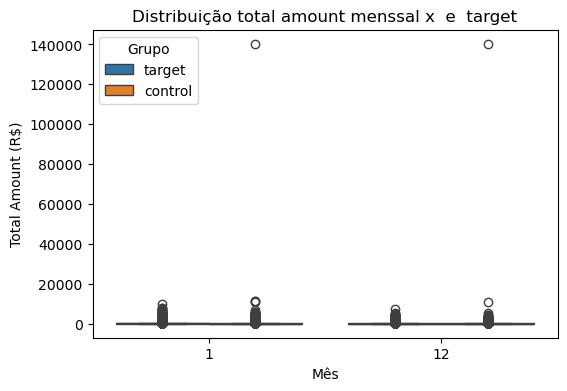

In [47]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=publico_janeiro_dezembro,
    y='total_amount_mes',
    x='order_created_month',  
    hue='is_target'          
)
plt.title('Distribuição total amount menssal x  e  target')
plt.ylabel('Total Amount (R$)')
plt.xlabel('Mês')
plt.legend(title='Grupo')
plt.show()

Observa-se grande numero de outliers, verificar a distribuicao removendo outliers.

In [48]:
publico_janeiro_dezembro['total_amount_mes'].describe().round(2)


count    1172472.00
mean         151.79
std          284.42
min            0.00
25%           42.90
50%           81.70
75%          173.20
max       140338.90
Name: total_amount_mes, dtype: float64

<Axes: >

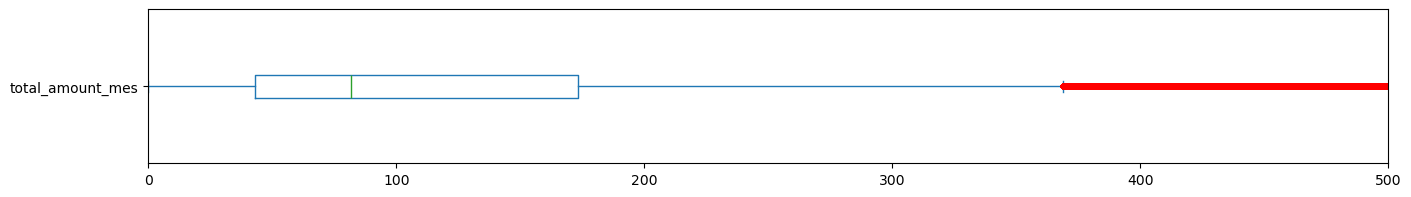

In [49]:
red_square = dict(markerfacecolor='r', markeredgecolor='r', marker='.')
publico_janeiro_dezembro['total_amount_mes'].plot(kind='box', xlim=(0, 500), vert=False, flierprops=red_square, figsize=(16,2))

In [ ]:
distance = 1.5 * (np.nanpercentile(publico_janeiro_dezembro['total_amount_mes'], 75) - np.nanpercentile(publico_janeiro_dezembro['total_amount_mes'], 25))
lim_sup=distance + np.nanpercentile(publico_janeiro_dezembro['total_amount_mes'], 75)

In [50]:
pb_drop = publico_janeiro_dezembro.drop(
    publico_janeiro_dezembro[
        (publico_janeiro_dezembro['total_amount_mes'] == 0) |
        (publico_janeiro_dezembro['total_amount_mes'] > lim_sup)
    ].index,
    axis=0
)

In [51]:
pb_drop['total_amount_mes'].describe().round(2)

count    1069237.00
mean         101.21
std           81.35
min            0.01
25%           40.00
50%           72.10
75%          138.98
max          368.65
Name: total_amount_mes, dtype: float64

<Axes: >

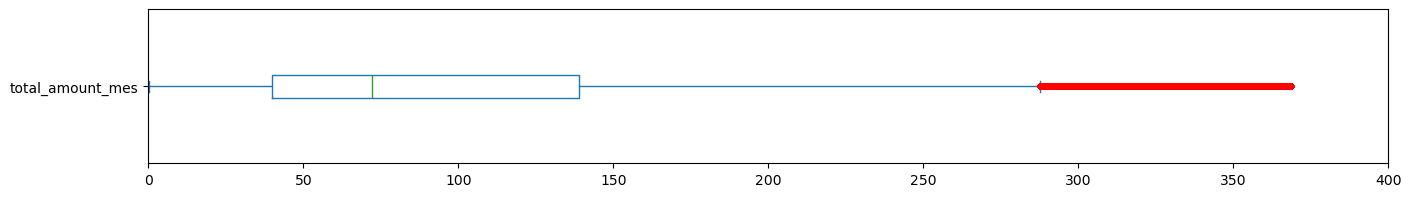

In [52]:
red_square = dict(markerfacecolor='r', markeredgecolor='r', marker='.')
pb_drop['total_amount_mes'].plot(kind='box', xlim=(0, 400), vert=False, flierprops=red_square, figsize=(16,2))

In [53]:
df_decil,decil_dict=cria_base_decil_wide(publico_janeiro_dezembro,
    mes_0=12,  
    mes_1=1,  
    col_cliente="customer_id",
    col_mes="order_created_month",
    col_pedidos="num_pedidos_mes",
    col_valor="total_amount_mes",
    col_target="is_target",  
    n_decis=10,
    prefixo_decil="decil",
    prefixo_pedidos="num_pedidos_mes",
    prefixo_valor="total_amount_mes"
)

/Users/maceli/ifood_cs/code/notebook/../utilities/functions.py:562: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  base_m0.groupby(col_decil_m0)[col_valor]


In [54]:
df_decil.head()

,customer_id,is_target,decil_1,decil_12,num_pedidos_mes_1,num_pedidos_mes_12,total_amount_mes_1,total_amount_mes_12
0,000009e29b12d8c5b9c9579e21384320c2df3bd935f19e...,control,decil 10,decil 7,8,2,273.00,100.00
1,000021924bf8192f64a7cc17ce7c0bc511cba907308f80...,target,decil 9,decil 8,3,2,173.90,119.90
2,000022ced2f3aa411b66ac41167b272ae528c4acdffeeb...,target,decil 6,decil 6,2,2,68.65,68.65
3,000032b594523c3f8868edee4f1577b157e115cd01ab31...,control,decil 7,decil 7,1,1,88.80,88.80
4,0000bb10fb47a1d6b2d73754ef383950ef536c77d07212...,control,decil 9,decil 9,2,2,188.19,188.19


In [55]:
save_parquet(df_decil, "../dados/gold", "df_decil.parquet")

💾 SALVO: dados/../dados/gold/df_decil.parquet
📁 Local: /Users/maceli/ifood_cs/code/notebook/dados/../dados/gold/df_decil.parquet


PosixPath('dados/../dados/gold/df_decil.parquet')

In [56]:
import os
os.makedirs('../dados/gold', exist_ok=True)

decil_dict_json = {k: list(v) for k, v in decil_dict.items()}
with open('../dados/gold/decil_dictionary.json', 'w') as f:
    json.dump(decil_dict_json, f, indent=2)

In [57]:
decil_summary=gerar_resumo_decis(df_decil)
decil_summary

,decil_12,decil_1,is_target,total_clientes,avg_amount_12,avg_amount_1,avg_pedidos_12,avg_pedidos_1,ticket_medio_12,ticket_medio_1
0,decil 1,decil 1,control,18701,18.22,18.31,1.01,1.02,18.03,17.96
1,decil 1,decil 1,target,18754,18.23,18.35,1.02,1.03,17.90,17.81
2,decil 1,decil 10,control,191,19.76,308.63,1.01,7.35,19.55,42.02
3,decil 1,decil 10,target,310,19.69,315.48,1.01,7.34,19.44,42.97
4,decil 1,decil 2,control,488,14.42,29.52,1.03,2.09,13.99,14.15
...,...,...,...,...,...,...,...,...,...,...
105,decil 8,decil 9,target,9304,122.82,185.27,2.86,4.50,42.88,41.15
106,decil 9,decil 10,control,13307,184.31,371.63,3.88,7.64,47.50,48.61
107,decil 9,decil 10,target,19800,184.49,374.09,3.91,7.74,47.22,48.35
108,decil 9,decil 9,control,9264,173.27,183.72,3.06,3.36,56.68,54.61


In [58]:
os.makedirs('../Resultados', exist_ok=True)

decil_summary.to_csv('../Resultados/decil_summary.csv', index=False)



Numero de pedidos em Janeiro e Dezembro para o quem esteve em ambos meses

In [64]:
publico_janeiro_dezembro.head()

,customer_id,origin_platform,is_target,order_created_month,num_pedidos_mes,num_pedidos_hist,total_amount_mes,ticket_medio
0,ffffeda85b466b48195c356f8b97f21d0b23958d5815fc...,DESKTOP,target,12,1,2,167.0,167.0
1,ffffeda85b466b48195c356f8b97f21d0b23958d5815fc...,DESKTOP,target,1,1,2,167.0,167.0
2,ffffe95dc11472a22c46b6d5cdc5c14cf40e0c88a601e0...,IOS,target,12,2,4,209.0,104.5
3,ffffe95dc11472a22c46b6d5cdc5c14cf40e0c88a601e0...,IOS,target,1,2,4,209.0,104.5
4,ffffe50aaaed54af0eb463fcc6761b0e17a1d1cdd6b8e1...,DESKTOP,control,12,1,2,55.6,55.6


In [90]:
# Primeira análise: por mês e número de pedidos
df_stats_mes = publico_janeiro_dezembro.groupby(['order_created_month', 'num_pedidos_mes']).agg(
    total_clientes=('customer_id', 'nunique')
).round(2)

df_stats_mes['pct_mes'] = df_stats_mes.groupby('order_created_month')['total_clientes'] \
                 .transform(lambda x: x / x.sum() * 100).round(2)

print("📊 Análise por Mês e Número de Pedidos:")
print(df_stats_mes.head(10))

# Segunda análise: pela categoria pedidos_sum
df_stats_hist = publico_janeiro_dezembro.groupby(['pedidos_sum']).agg(
    total_clientes=('customer_id', 'nunique')
).round(2)

df_stats_hist['pct_total'] = (df_stats_hist['total_clientes'] / df_stats_hist['total_clientes'].sum() * 100).round(2)

print("\n📈 Análise por Categoria de Pedidos:")
print(df_stats_hist.head(20))

📊 Análise por Mês e Número de Pedidos:
                                     total_clientes  pct_mes
order_created_month num_pedidos_mes                         
1                   1                        195166    35.20
                    2                        106593    19.23
                    3                         67767    12.22
                    4                         46341     8.36
                    5                         32575     5.88
                    6                         23456     4.23
                    7                         17248     3.11
                    8                         13125     2.37
                    9                          9968     1.80
                    10                         7742     1.40

📈 Análise por Categoria de Pedidos:
             total_clientes  pct_total
pedidos_sum                           
1                    300412      36.46
10                    10047       1.22
10+                   34395       4.

In [ ]:

df_stats_hist = publico_janeiro_dezembro.groupby(['pedidos_sum']).agg(
    total_clientes=('customer_id', 'nunique')  # COUNT DISTINCT
).round(2)

df_stats_hist['pct_total'] = (df_stats_hist['total_clientes'] / df_stats_hist['total_clientes'].sum() * 100).round(2)

df_stats_hist.head(20)

,total_clientes,pct_total
pedidos_sum,,
1,300412,36.46
10,10047,1.22
10+,34395,4.17
2,167956,20.38
3,105291,12.78
4,69756,8.47
5,47569,5.77
6,33525,4.07
7,23958,2.91


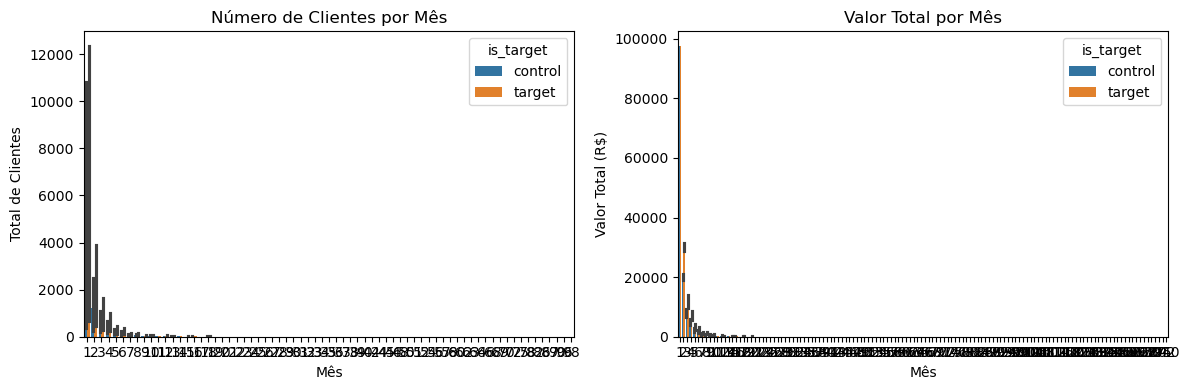

In [63]:
# Gráfico 1 - Total de clientes por mês e grupo
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)  # 1 linha, 2 colunas, posição 1
sns.barplot(
    data=pedidos_hist,
    x='Total_Pedidos_Mes_12',
    y='Total_Clientes',
    hue='is_target'
)
plt.title('Número de Clientes por Mês')
plt.ylabel('Total de Clientes')
plt.xlabel('Mês')

# Gráfico 2 - Valor total por mês e grupo
plt.subplot(1, 2, 2)  # 1 linha, 2 colunas, posição 2
sns.barplot(
    data=pedidos_hist,
    x='Total_Pedidos_Mes_1',
    y='Total_Clientes',
    hue='is_target'
)
plt.title('Valor Total por Mês')
plt.ylabel('Valor Total (R$)')
plt.xlabel('Mês')

plt.tight_layout()
plt.show()

In [94]:
publico_janeiro_dezembro.head()

,customer_id,origin_platform,is_target,order_created_month,num_pedidos_mes,num_pedidos_hist,total_amount_mes,ticket_medio,pedidos_sum
0,ffffeda85b466b48195c356f8b97f21d0b23958d5815fc...,DESKTOP,target,12,1,2,167.0,167.0,1
1,ffffeda85b466b48195c356f8b97f21d0b23958d5815fc...,DESKTOP,target,1,1,2,167.0,167.0,1
2,ffffe95dc11472a22c46b6d5cdc5c14cf40e0c88a601e0...,IOS,target,12,2,4,209.0,104.5,2
3,ffffe95dc11472a22c46b6d5cdc5c14cf40e0c88a601e0...,IOS,target,1,2,4,209.0,104.5,2
4,ffffe50aaaed54af0eb463fcc6761b0e17a1d1cdd6b8e1...,DESKTOP,control,12,1,2,55.6,55.6,1


In [95]:

pedidos_hist=resumo_coorte_ativa(publico_janeiro_dezembro,mes_coorte_inicio=12,mes_coorte_fim=1)
#pedidos_hist['pct_mes'] = pedidos_hist.groupby('order_created_month')['Total_Clientes'] \
                # .transform(lambda x: x / x.sum() * 100).round(2)

pedidos_hist

,is_target,Total_Pedidos_Mes_1,Total_Pedidos_Mes_12,Total_Clientes
0,control,1,1,97595
1,control,2,1,20904
2,control,2,2,19044
3,control,3,1,9234
4,control,3,2,8796
...,...,...,...,...
2413,target,170,90,1
2414,target,177,20,1
2415,target,184,78,1
2416,target,202,98,1


In [60]:
pedidos_hist.to_csv('../Resultados/pedidos_hist.csv', index=False)